# Práctica Deep Learning
Adolfo Capellades

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from keras import regularizers
import kagglehub

import cv2

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## Definimos parámetros

In [2]:
image_size = (28, 28)
batch_size = 128
epochs = 10
learning_rate_frozen = 1e-3
learning_rate_finetune = 1e-5

## Datos HAM10000

Origen: Dataset de Kaggle.
- No contiene duplicados (key: lesion_id, image_id)
- No hay datos erróneos (mismatch)
- No hay datos faltantes excepto en campo age (0,5%)

In [3]:
from kagglehub import KaggleDatasetAdapter

file_path_md = "HAM10000_metadata.csv"

# Load the latest version
df_md = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "kmader/skin-cancer-mnist-ham10000",
    file_path_md
)

print("First 5 records md:", df_md.head())


Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
First 5 records md:      lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


In [4]:
df_md.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [5]:
# Path de los datos
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Path to dataset files:", path)

# Path de las imágenes
images_dir_part1 = os.path.join(path, "HAM10000_images_part_1")
images_dir_part2 = os.path.join(path, "HAM10000_images_part_2")


Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


Añadimos columna con el _path_ de las imágenes

In [6]:
#ids = df_md["image_id"].astype(str)
df_md["img_path"] = df_md["image_id"].astype(str).apply(lambda x: os.path.join(
    images_dir_part1 if x < "ISIC_0029306" else images_dir_part2,
    f"{x}.jpg"
))

In [7]:
df_md.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
 7   img_path      10015 non-null  object 
dtypes: float64(1), object(7)
memory usage: 626.1+ KB


In [8]:
for x in df_md["image_id"].astype(str).head(7):
    folder = images_dir_part1 if x < "ISIC_0029306" else images_dir_part2
    print(os.path.join(folder, f"{x}.jpg"))

/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027419.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0025030.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0026769.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0025661.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2/ISIC_0031633.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027850.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0029176.jpg


Convierto la columna dx (ground-truth) en numérica (`label`).

In [9]:
class_names = sorted(df_md["dx"].unique().tolist())
class_to_index = {name: i for i, name in enumerate(class_names)}
df_md["label"] = df_md["dx"].map(class_to_index).astype(np.int32)

Calculamos los pesos que tienen cada clase dentro de la distribución para aplicarlo en el fit y evitar el _overfitting_.



`NOTA:` Esta solución viene de un diálogo con _Claude_ en el cual estaba buscando una forma limpia de evitar el overfitting. He aplicado _batch normalization_, _dropout_, _global_max_pooling_; no he aplicado regularización porque no sé cómo hacerlo. En este diálogo en el cual le pedía orientación, no la solución directa, y estirando del hilo a partir de `model.fit(class_weight ... )`, implemento la solución de abajo que cumple con mi propósito: limpia y "sencilla", evitando _upsampling_ y _downsampling_ que me parecía una solución más complicada y en la cual debía distorcionar el dataset original. Tampoco aplico _data augmentation_ para las imágenes.


In [10]:
from sklearn.utils.class_weight import compute_class_weight

class_names = np.array(class_names)

dx_class_weights = compute_class_weight(class_weight="balanced", classes=class_names, y=df_md["dx"])

Creo el diccionario de pesos a partir de los pesos calculados con `compte_class_weight`

In [11]:
print(class_names)
print(dx_class_weights)
print(df_md.groupby(by="dx")[["dx"]].count())
#total_df_md_dx = df_md[["dx"]].count()
#xx = df_md.groupby(by="dx")[["dx"]].count()
#print(xx.iloc[4:6,:])
#for x, y in xx:
#  print(x, y)
#print('Total:', df_md[["dx"]].count())
weight_dict = {}
for pos, cn in enumerate(class_names):
  weight_dict[pos] = float(dx_class_weights[pos])

print(weight_dict)

['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']
[ 4.37527304  2.78349083  1.30183284 12.44099379  1.28545758  0.21338021
 10.07545272]
         dx
dx         
akiec   327
bcc     514
bkl    1099
df      115
mel    1113
nv     6705
vasc    142
{0: 4.375273044997815, 1: 2.78349082823791, 2: 1.301832835044846, 3: 12.440993788819876, 4: 1.2854575792581184, 5: 0.21338020666879728, 6: 10.075452716297788}


## Preprocesado (primera parte)

In [12]:
# Visualizamos estadísticas de columna 'age'
df_md["age"].describe()

,age
count,9958.000000
mean,51.863828
std,16.968614
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


In [13]:
df_md["age"].skew() # vemos la "desviación" de los valores campo 'age'

np.float64(-0.16680239035840475)

Columna 'age'. Tenemos datos que representan el 0,5% que no están informados.

Imputamos con la media para rellenar

In [14]:

imputer = SimpleImputer(strategy="mean")
df_md[["age"]] = imputer.fit_transform(df_md[["age"]] )
df_md[["age"]] = df_md[["age"]].values.astype("int32")

In [15]:
df_md.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   lesion_id     10015 non-null  object
 1   image_id      10015 non-null  object
 2   dx            10015 non-null  object
 3   dx_type       10015 non-null  object
 4   age           10015 non-null  int32 
 5   sex           10015 non-null  object
 6   localization  10015 non-null  object
 7   img_path      10015 non-null  object
 8   label         10015 non-null  int32 
dtypes: int32(2), object(7)
memory usage: 626.1+ KB


In [16]:
print('Cols: ', df_md.columns)
print('Shape: ', df_md.shape)

Cols:  Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'img_path', 'label'],
      dtype='object')
Shape:  (10015, 9)


In [17]:
a = df_md["dx"].unique()
#for val in a:
print(df_md.groupby(by=["dx"])[["dx"]].count())
#print(a)
df_md.shape

         dx
dx         
akiec   327
bcc     514
bkl    1099
df      115
mel    1113
nv     6705
vasc    142


(10015, 9)

## Split

Antes de continuar con la codificación de las categorías (one hot) o la normalización y, sobre todo antes de eliminar columnas para el dataset tabular, realizamos el split del dataset en train, validation y test.

~*The stratify parameter ensures that if you have a dataset with 80 observations of class A and 20 of class B, and you set stratify=True, the train and test sets will maintain this 80:20 ratio when split.*~

No utilizo la estratificación porque he tenido que cambiar la estrategia para dividir los datos (agradecimientos a Fran).

In [18]:
# Feat. Fran
df_lesion_id = df_md["lesion_id"].unique()

In [19]:
df_lesion_id

array(['HAM_0000118', 'HAM_0002730', 'HAM_0001466', ..., 'HAM_0005579',
       'HAM_0001576', 'HAM_0002867'], dtype=object)

Realizo el split en train, val y test.

In [20]:
# datos tabulares
train_df_id, temp_df_id = train_test_split(
    df_lesion_id,
    test_size=0.25,
    #stratify=df_lesion_id[["lesion_id"]]
)

val_df_id, test_df_id = train_test_split(
    temp_df_id,
    test_size=0.5,
)

In [21]:
train_df = df_md[df_md['lesion_id'].isin(train_df_id)]
test_df = df_md[df_md['lesion_id'].isin(test_df_id)]
val_df = df_md[df_md['lesion_id'].isin(val_df_id)]

In [22]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7516 entries, 0 to 10014
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   lesion_id     7516 non-null   object
 1   image_id      7516 non-null   object
 2   dx            7516 non-null   object
 3   dx_type       7516 non-null   object
 4   age           7516 non-null   int32 
 5   sex           7516 non-null   object
 6   localization  7516 non-null   object
 7   img_path      7516 non-null   object
 8   label         7516 non-null   int32 
dtypes: int32(2), object(7)
memory usage: 528.5+ KB


In [23]:
print("Classes:", class_names)
print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))
#print("Tabular feature dimension:", X_train_tab.shape[1])

Classes: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']
Train size: 7516
Val size: 1248
Test size: 1251


In [24]:
# Verificación de leakeage por image_id
campo = "lesion_id"
count_test = test_df[campo].count()

count_val = val_df[campo].count()
x = train_df.merge(test_df, left_on=campo, right_on=campo,how="inner")
x[campo].count()
print("Valores filtrados (train-test):", x[campo].count())
x = train_df.merge(val_df, left_on=campo, right_on=campo,how="inner")
print("Valores filtrados (train-val):", x[campo].count())
x = test_df.merge(val_df, left_on=campo, right_on=campo,how="inner")
print("Valores filtrados (val-test):", x[campo].count())


Valores filtrados (train-test): 0
Valores filtrados (train-val): 0
Valores filtrados (val-test): 0


- ~Quitamos las columnas _lesion\_id_ e _image\_id_ porque no aportan información al análisis tabular~
- Normalizamos el resto de columnas con one-hot-encoder (matriz de posibilidades para todos los valores de la columna)

In [26]:
#one-hot encoding
cols2ohe = ["dx_type", "sex", "localization"]

train_df = pd.get_dummies(train_df, columns=cols2ohe, dtype=int)
test_df= pd.get_dummies(test_df, columns=cols2ohe, dtype=int)
val_df= pd.get_dummies(val_df, columns=cols2ohe, dtype=int)

# Ayuda de Claude para solucionar la disparidad de columnas
test_df = test_df.reindex(columns=train_df.columns, fill_value=0)
val_df  = val_df.reindex(columns=train_df.columns, fill_value=0)

In [27]:
print('train:',len(train_df.columns))
print('test:',len(test_df.columns))
print('val:',len(val_df.columns))

train: 28
test: 28
val: 28


In [28]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7516 entries, 0 to 10014
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   lesion_id                     7516 non-null   object
 1   image_id                      7516 non-null   object
 2   dx                            7516 non-null   object
 3   age                           7516 non-null   int32 
 4   img_path                      7516 non-null   object
 5   label                         7516 non-null   int32 
 6   dx_type_confocal              7516 non-null   int64 
 7   dx_type_consensus             7516 non-null   int64 
 8   dx_type_follow_up             7516 non-null   int64 
 9   dx_type_histo                 7516 non-null   int64 
 10  sex_female                    7516 non-null   int64 
 11  sex_male                      7516 non-null   int64 
 12  sex_unknown                   7516 non-null   int64 
 13  localization_abdomen  

indx:868 (450, 600, 3)


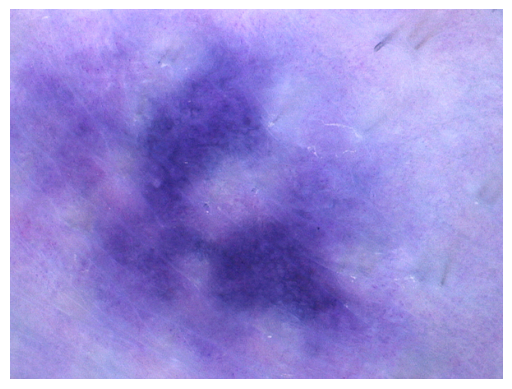

In [29]:
import matplotlib.pyplot as plt

idx = np.random.randint(2300)
row = train_df.iloc[idx]
image_path = row["img_path"]
#image_path = images_dir_part1 + "/" + "ISIC_0028576" + ".jpg"
image = cv2.imread(image_path)#[:, :, ::-1]

print(f"indx:{idx}",image.shape)

plt.imshow(image)
plt.axis("off")
plt.show()

#print(row)

Utilizo la función del ejemplo (notebook 6) para crear el dataset a aplicar a cada uno de los modelos.

In [30]:
def load_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, image_size)
    #image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    # normalizamos la imagen
    image = image / 255.
    return image


def make_dataset(tabular_array, image_paths, labels, training):
    tab_array_f32 = tf.cast(tabular_array, tf.float32)
    ds = tf.data.Dataset.from_tensor_slices((tab_array_f32, image_paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(labels), reshuffle_each_iteration=True)

    def mapper(tabular, image_path, label):
        image = load_image(image_path)
        return {"tabular_input": tabular, "image_input": image}, label

    ds = ds.map(mapper)
    ds = ds.batch(batch_size)
    return ds

Definimos los datasets de entrenamiento, test y validación

In [31]:
cols2drop = ["dx","lesion_id", "image_id","img_path"]

X_train_tab = train_df.drop(columns=cols2drop)
X_val_tab   = val_df.drop(columns=cols2drop)
X_test_tab  = test_df.drop(columns=cols2drop)

In [32]:
X_test_tab.groupby(by="label")["label"].count()

,label
label,
0,46
1,50
2,158
3,13
4,123
5,846
6,15


In [33]:
print("Train distribution:")
print(train_df["dx"].value_counts(normalize=True))
print("\nVal distribution:")
print(val_df["dx"].value_counts(normalize=True))

Train distribution:
dx
nv       0.663252
mel      0.113890
bkl      0.107238
bcc      0.054284
akiec    0.033528
vasc     0.016232
df       0.011575
Name: proportion, dtype: float64

Val distribution:
dx
nv       0.700321
bkl      0.108173
mel      0.107372
bcc      0.044872
akiec    0.023237
df       0.012019
vasc     0.004006
Name: proportion, dtype: float64


In [34]:
X_val_tab.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1248 entries, 11 to 10002
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   age                           1248 non-null   int32
 1   label                         1248 non-null   int32
 2   dx_type_confocal              1248 non-null   int64
 3   dx_type_consensus             1248 non-null   int64
 4   dx_type_follow_up             1248 non-null   int64
 5   dx_type_histo                 1248 non-null   int64
 6   sex_female                    1248 non-null   int64
 7   sex_male                      1248 non-null   int64
 8   sex_unknown                   1248 non-null   int64
 9   localization_abdomen          1248 non-null   int64
 10  localization_acral            1248 non-null   int64
 11  localization_back             1248 non-null   int64
 12  localization_chest            1248 non-null   int64
 13  localization_ear              1248 n

In [35]:
train_paths = train_df["img_path"].astype(str).values
val_paths   = val_df["img_path"].astype(str).values
test_paths  = test_df["img_path"].astype(str).values

In [36]:
y_train = train_df["label"].values.astype("int32")
y_val   = val_df["label"].values.astype("int32")
y_test  = test_df["label"].values.astype("int32")

In [37]:
train_ds = make_dataset(X_train_tab, train_paths, y_train, training=True)
val_ds   = make_dataset(X_val_tab,   val_paths,   y_val,   training=False)
test_ds  = make_dataset(X_test_tab,  test_paths,  y_test,  training=False)

## Modelo 1D

Modelo 1D (tabular): Resolver el problema considerando únicamente la información
presente en los datos tabulares (sexo, edad, parte del cuerpo).

In [38]:
tabular_input = tf.keras.Input(shape=(X_train_tab.shape[1],), name="tabular_input")
x_tab = tf.keras.layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=regularizers.L1(0.01)
    )(tabular_input)
x_tab = tf.keras.layers.BatchNormalization()(x_tab)
x_tab = tf.keras.layers.Dropout(0.4)(x_tab)

x_tab = tf.keras.layers.Dense(64, activation="relu")(x_tab)
#x_tab = tf.keras.layers.Dense(32, activation="relu")(tabular_input)
#x_tab = tf.keras.layers.Dense(24, activation="relu")(tabular_input)
x_tab = tf.keras.layers.BatchNormalization()(x_tab)
x_tab = tf.keras.layers.Dropout(0.3)(x_tab)

x_tab = tf.keras.layers.Dense(32, activation="relu")(x_tab)
#x_tab = tf.keras.layers.Dense(12, activation="relu")(x_tab)
x_tab = tf.keras.layers.BatchNormalization()(x_tab)
x_tab = tf.keras.layers.Dropout(0.2)(x_tab)

output1d = tf.keras.layers.Dense(len(class_names), activation="softmax", name="output1d")(x_tab)

In [39]:
model_t = tf.keras.Model(inputs=[tabular_input], outputs=output1d)

In [40]:
model_t.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate_frozen),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [41]:
epochs_t = 20

In [42]:
# Preservamos los mejores pesos. El entrenamiento se para cuando encuentra los mejores pesos
callback_t = keras.callbacks.EarlyStopping(
      monitor='val_loss',
      baseline=None,
      patience=3,
      restore_best_weights=True,
      verbose=1)

In [43]:
model1d = model_t.fit(train_ds,
      validation_data=val_ds,
      class_weight=weight_dict,
      callbacks=[callback_t],
      epochs=epochs_t
  )

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 58s 863ms/step - accuracy: 0.1583 - loss: 4.5999 - val_accuracy: 0.1803 - val_loss: 4.0753
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 48s 815ms/step - accuracy: 0.2670 - loss: 3.1004 - val_accuracy: 0.5393 - val_loss: 2.5548
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 43s 732ms/step - accuracy: 0.3764 - loss: 2.1654 - val_accuracy: 0.7332 - val_loss: 1.7934
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 42s 713ms/step - accuracy: 0.5129 - loss: 1.5773 - val_accuracy: 0.7949 - val_loss: 1.4418
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 47s 796ms/step - accuracy: 0.6024 - loss: 1.3169 - val_accuracy: 0.8662 - val_loss: 1.2470
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 45s 750ms/step - accuracy: 0.6722 - loss: 1.1004 - val_accuracy: 0.7163 - val_loss: 1.2655
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 84s 801ms/step - accuracy: 0.7259 - loss: 0.9495 - val_accuracy: 0.8870 - val_loss: 0.9802
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 43s 729ms/step - accuracy: 0.7710 - loss: 0.8680 - val_accu

Función para graficar los resultados del entrenamiento.

In [109]:
def train_val_plot(model_his, acc_loss):
  '''
  Muestra las gráficas de ejecución entre datos de train y val

  model_his : model.history
  acc_loss  : 'acc|loss'. Switch para ver `accuracy` o `loss`
  '''

  print(type(model_his))

  match acc_loss:
    case 'acc':
      train_acc = model_his['accuracy']
      val_acc = model_his['val_accuracy']
      label_text = "Accuracy"
      color_train='b'
      color_val='g'
    case 'loss':
      train_acc = model_his['loss']
      val_acc = model_his['val_loss']
      label_text = "Loss"
      color_train='#FFC000'
      color_val='r'
    case _:
      raise ValueError('Invalid parameter value `acc_loss`. Correct values: acc|loss')


  # Plot
  plt.figure(figsize=(8, 5))
  plt.plot(train_acc, label='Training ' + label_text , marker='o', color=color_train)
  plt.plot(val_acc,   label='Validation ' + label_text , marker='s', color=color_val)
  plt.title('Training vs Validation '+ label_text )
  plt.xlabel('Epochs')
  plt.ylabel(label_text)
  plt.legend()
  plt.grid(True, linestyle='--', alpha=0.6)
  plt.tight_layout()
  plt.show()

<class 'dict'>


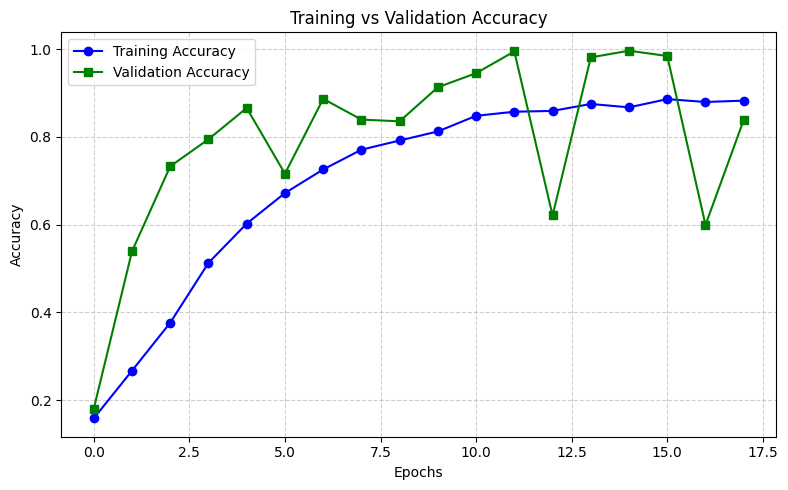

In [110]:
train_val_plot(model1d.history, 'acc')

<class 'dict'>


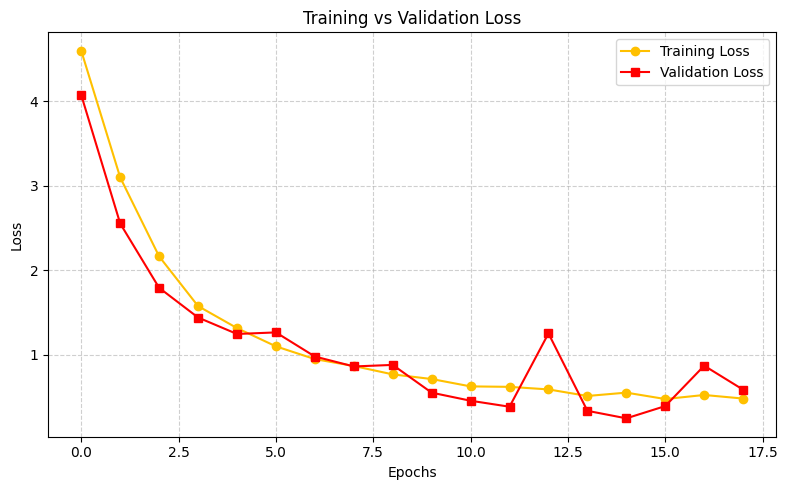

In [111]:
train_val_plot(model1d.history, 'loss')

## Modelo 2D

Modelo 2D (imágenes): Resolver el problema considerando la información presente
en las imágenes empleando para ello al menos una red convolucional.

In [47]:
image_input = tf.keras.Input(shape=(image_size[0], image_size[1], 3), name="image_input")
image_input

<KerasTensor shape=(None, 28, 28, 3), dtype=float32, sparse=False, ragged=False, name=image_input>

In [48]:
# modelo convolucional
image_input = tf.keras.Input(shape=(image_size[0], image_size[1], 3), name="image_input")

x_feat = tf.keras.layers.Conv2D(32, kernel_size=3)(image_input)
x_feat = tf.keras.layers.BatchNormalization()(x_feat)
x_feat = tf.keras.layers.ReLU()(x_feat)
x_feat = tf.keras.layers.MaxPool2D((2, 2))(x_feat)

x_feat = tf.keras.layers.Conv2D(64, kernel_size=3)(x_feat)
x_feat = tf.keras.layers.BatchNormalization()(x_feat)
x_feat = tf.keras.layers.ReLU()(x_feat)
x_feat = tf.keras.layers.MaxPool2D((2, 2))(x_feat)

krnl_reg = tf.keras.regularizers.l2(1e-3)
x_feat = tf.keras.layers.Conv2D(128,
                                kernel_size=3,
                                kernel_regularizer = krnl_reg
                               )(x_feat)
x_feat = tf.keras.layers.BatchNormalization()(x_feat)
x_feat = tf.keras.layers.ReLU()(x_feat)
x_feat = tf.keras.layers.MaxPool2D((2, 2))(x_feat)

x_pooled = tf.keras.layers.GlobalAveragePooling2D()(x_feat)
#x_pooled = tf.keras.layers.Flatten()(x_pooled)

#x_concat = tf.keras.layers.Concatenate()([x_tab, x_pooled])

#x = tf.keras.layers.Dense(128, activation="relu")(x_concat)
x = tf.keras.layers.Dense(128, activation="relu")(x_pooled)
x = tf.keras.layers.Dropout(0.3)(x)
output2d = tf.keras.layers.Dense(len(class_names), activation="softmax", name="output2d")(x)

In [49]:
#model = tf.keras.Model(inputs=[tabular_input, image_input], outputs=output)
model_i = tf.keras.Model(inputs=[image_input], outputs=output2d)

In [50]:
model_i.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output2d (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,559 (435.78 KB)

 Trainable params: 111,111 (434.03 KB)

 Non-trainable params: 448 (1.75 KB)

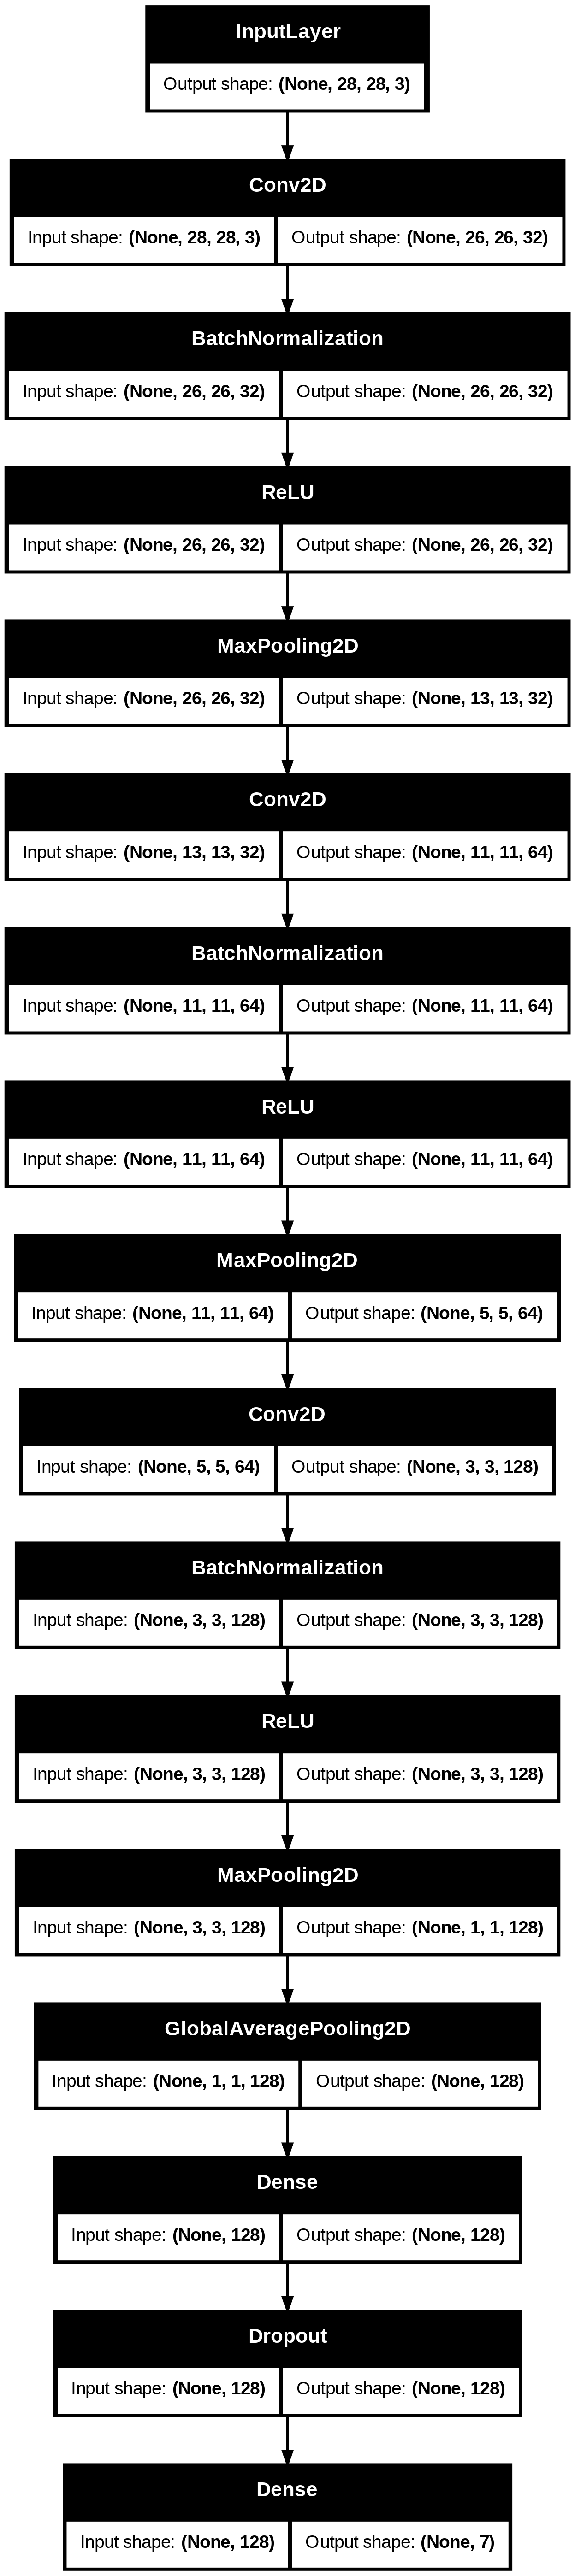

In [51]:
from tensorflow.keras.utils import plot_model
plot_model(model_i, show_shapes=True)

In [52]:
learning_rate_conv=1e-4

In [53]:
model_i.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate_conv),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)



In [54]:
callback_i = keras.callbacks.EarlyStopping(
      monitor='val_loss',
      baseline=None,
      patience=3,
      restore_best_weights=True,
      verbose=1)

In [55]:
epochs_i = 20

In [56]:
model2d = model_i.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_i,
    callbacks=[callback_i]
)

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 58s 931ms/step - accuracy: 0.5362 - loss: 1.4775 - val_accuracy: 0.6811 - val_loss: 1.8245
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 56s 954ms/step - accuracy: 0.6827 - loss: 1.0112 - val_accuracy: 0.3846 - val_loss: 1.6986
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 76s 856ms/step - accuracy: 0.6994 - loss: 0.9505 - val_accuracy: 0.5689 - val_loss: 1.6050
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 87s 947ms/step - accuracy: 0.7081 - loss: 0.9017 - val_accuracy: 0.6803 - val_loss: 1.4553
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 51s 850ms/step - accuracy: 0.7203 - loss: 0.8722 - val_accuracy: 0.7155 - val_loss: 1.2745
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 51s 869ms/step - accuracy: 0.7195 - loss: 0.8432 - val_accuracy: 0.7236 - val_loss: 1.0656
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 51s 870ms/step - accuracy: 0.7320 - loss: 0.8231 - val_accuracy: 0.7212 - val_loss: 0.9721
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 85s 920ms/step - accuracy: 0.7384 - loss: 0.7954 - val_accu

<class 'dict'>


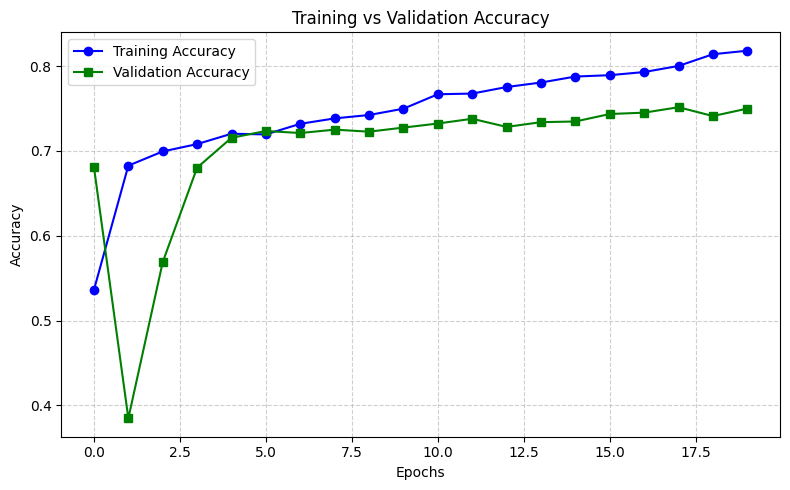

In [57]:
train_val_plot(model2d.history, 'acc')

<class 'dict'>


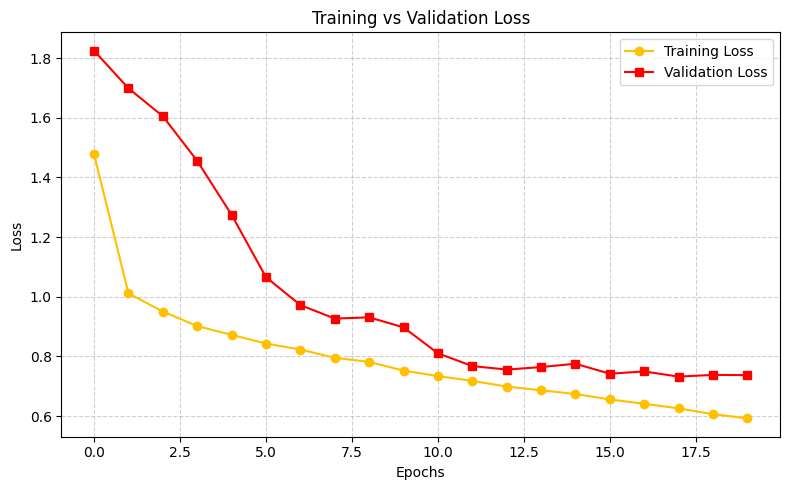

In [112]:
train_val_plot(model2d.history, 'loss')

## Late fusion

Estrategia late-fusion: Combinación aprendida de las predicciones realizadas por el
modelo 1D y el modelo 2D desarrollados previamente para resolver el problema.

In [59]:
# Congelamos los pesos de los modelos entrenados
model_t.trainable = False
model_i.trainable = False

In [60]:
callback_lf = keras.callbacks.EarlyStopping(
      monitor='val_loss',
      baseline=None,
      patience=3,
      restore_best_weights=True,
      verbose=1)

In [61]:
def build_late_fusion_model():
    # Consideramos los mismos inputs que cada modelo por separado
    tabular_input = model_t.input #tf.keras.Input(shape=(X_train_tab.shape[1],), name="tabular_input")
    image_input = model_i.input #tf.keras.Input(shape=(image_size[0], image_size[1], 3), name="image_input")

    # Obtenemos las predicciones finales para cada modalidad
    tabular_pred = model_t.output
    image_pred = model_i.output

    # Fusión de las probabilidades concatenadas
    merged = tf.keras.layers.Concatenate()([tabular_pred, image_pred])
    output = tf.keras.layers.Dense(len(class_names), activation="softmax", name="final_output")(merged)

    # Definición final del modelo con nuevo classificador al final
    late_fusion_model = tf.keras.Model(inputs={"tabular_input":tabular_input, "image_input": image_input}, outputs=output)
    return late_fusion_model



In [62]:
model_lf = build_late_fusion_model()
model_lf.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 28, 28, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 26, 26,    │        896 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 26, 26,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 26, 26,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 13, 13,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 11, 11,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_input       │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 11, 11,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      3,200 │ tabular_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 11, 11,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 5, 5, 64)  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 3, 3, 128) │     73,856 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3, 3, 128) │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 3, 3, 128) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 126,327 (493.46 KB)

 Trainable params: 105 (420.00 B)

 Non-trainable params: 126,222 (493.05 KB)

In [66]:
epochs_lf = 20
learning_rate_lf = 1e-4

In [67]:
model_lf.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate_lf),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [68]:
history_lf = model_lf.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_lf,
    callbacks=[callback_lf]
)

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 50s 820ms/step - accuracy: 0.7395 - loss: 1.4764 - val_accuracy: 0.7965 - val_loss: 1.4217
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 45s 763ms/step - accuracy: 0.7400 - loss: 1.4584 - val_accuracy: 0.7957 - val_loss: 1.4032
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 81s 741ms/step - accuracy: 0.7406 - loss: 1.4406 - val_accuracy: 0.7933 - val_loss: 1.3850
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 86s 801ms/step - accuracy: 0.7355 - loss: 1.4257 - val_accuracy: 0.7909 - val_loss: 1.3672
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 45s 766ms/step - accuracy: 0.7394 - loss: 1.4067 - val_accuracy: 0.7893 - val_loss: 1.3496
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 47s 801ms/step - accuracy: 0.7395 - loss: 1.3920 - val_accuracy: 0.7877 - val_loss: 1.3323
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 80s 765ms/step - accuracy: 0.7424 - loss: 1.3745 - val_accuracy: 0.7845 - val_loss: 1.3153
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 85s 821ms/step - accuracy: 0.7382 - loss: 1.3594 - val_accu

<class 'dict'>


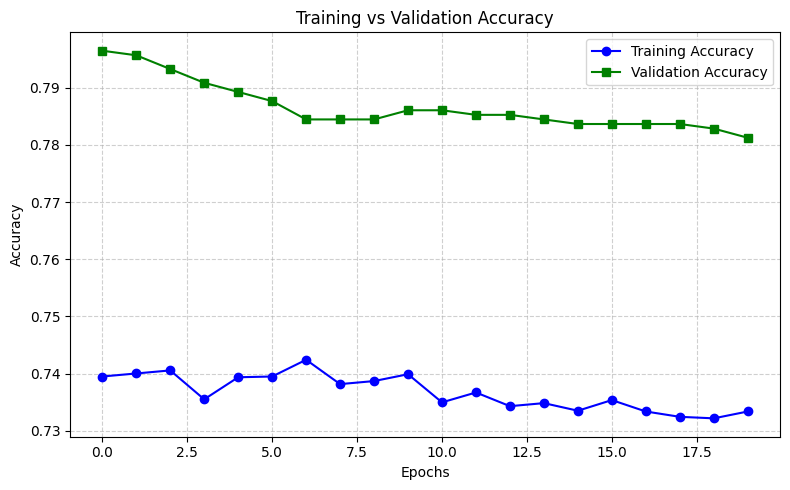

In [69]:
train_val_plot(history_lf.history, 'acc')

<class 'dict'>


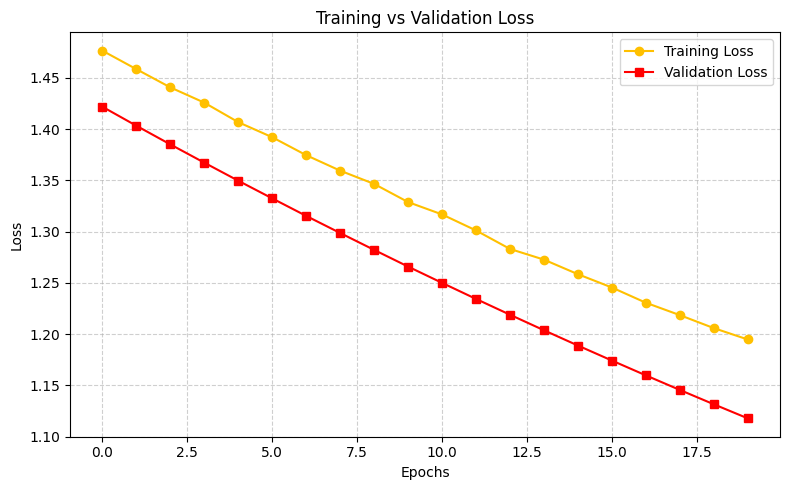

In [113]:
train_val_plot(history_lf.history, 'loss')

## Early fusion

Estrategia early-fusion: Combinación aprendida de las características realizadas por
el modelo 1D y el modelo 2D desarrollados previamente para resolver el problema.

In [94]:
# modelo tabular
tabular_input = tf.keras.Input(shape=(X_train_tab.shape[1],), name="tabular_input")
#^^^^^^^^^^^^
ef_tab = tf.keras.layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=regularizers.L1(0.01)
    )(tabular_input)
#     ^^^^^^^^^^^^^
ef_tab = tf.keras.layers.BatchNormalization()(ef_tab)
ef_tab = tf.keras.layers.Dropout(0.4)(ef_tab)

ef_tab = tf.keras.layers.Dense(64, activation="relu")(ef_tab)
ef_tab = tf.keras.layers.BatchNormalization()(ef_tab)
ef_tab = tf.keras.layers.Dropout(0.3)(ef_tab)

ef_tab = tf.keras.layers.Dense(32, activation="relu")(ef_tab)
ef_tab = tf.keras.layers.BatchNormalization()(ef_tab)
ef_tab = tf.keras.layers.Dropout(0.2)(ef_tab)


In [95]:
# modelo convolucional
image_input = tf.keras.Input(shape=(image_size[0], image_size[1], 3), name="image_input")
#^^^^^^^^^^
ef_feat = tf.keras.layers.Conv2D(32, kernel_size=3)(image_input)
#                                                   ^^^^^^^^^^^
ef_feat = tf.keras.layers.BatchNormalization()(ef_feat)
ef_feat = tf.keras.layers.ReLU()(ef_feat)
ef_feat = tf.keras.layers.MaxPool2D((2, 2))(ef_feat)

ef_feat = tf.keras.layers.Conv2D(64, kernel_size=3)(ef_feat)
ef_feat = tf.keras.layers.BatchNormalization()(ef_feat)
ef_feat = tf.keras.layers.ReLU()(ef_feat)
ef_feat = tf.keras.layers.MaxPool2D((2, 2))(ef_feat)

krnl_reg = tf.keras.regularizers.l2(1e-3)
ef_feat = tf.keras.layers.Conv2D(128,
                                kernel_size=3,
                                kernel_regularizer = krnl_reg
                               )(ef_feat)
ef_feat = tf.keras.layers.BatchNormalization()(ef_feat)
ef_feat = tf.keras.layers.ReLU()(ef_feat)
ef_feat = tf.keras.layers.MaxPool2D((2, 2))(ef_feat)

ef_pooled = tf.keras.layers.GlobalAveragePooling2D()(ef_feat)
#ef_pooled = tf.keras.layers.Flatten()(ef_pooled)

# Concatenación
ef_concat = tf.keras.layers.Concatenate()([ef_tab, ef_pooled])

x = tf.keras.layers.Dense(128, activation="relu")(ef_pooled)
x = tf.keras.layers.Dropout(0.3)(x)

# Características
output_ef = tf.keras.layers.Dense(len(class_names), activation="softmax", name="output")(x)

In [96]:
callback_ef = keras.callbacks.EarlyStopping(
      monitor='val_loss',
      baseline=None,
      patience=3,
      restore_best_weights=True,
      verbose=1)

In [97]:
model_ef = tf.keras.Model(inputs={"tabular_input":tabular_input, "image_input": image_input}, outputs=output_ef)

In [98]:
model_ef.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 28, 28, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 26, 26,    │        896 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 26, 26,    │        128 │ conv2d_24[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_24 (ReLU)     │ (None, 26, 26,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_24    │ (None, 13, 13,    │          0 │ re_lu_24[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 11, 11,    │     18,496 │ max_pooling2d_24… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 11, 11,    │        256 │ conv2d_25[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_25 (ReLU)     │ (None, 11, 11,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_25    │ (None, 5, 5, 64)  │          0 │ re_lu_25[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 3, 3, 128) │     73,856 │ max_pooling2d_25… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3, 3, 128) │        512 │ conv2d_26[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_26 (ReLU)     │ (None, 3, 3, 128) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_26    │ (None, 1, 1, 128) │          0 │ re_lu_26[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_26… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 128)       │          0 │ dense_25[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_input       │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 7)         │        903 │ dropout_25[0][0]

 Total params: 111,559 (435.78 KB)

 Trainable params: 111,111 (434.03 KB)

 Non-trainable params: 448 (1.75 KB)

In [99]:
epochs_ef = 20
learning_rate_ef = 1e-3

In [100]:
model_ef.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate_ef),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [101]:
history_ef = model_ef.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_ef,
    callbacks=[callback_ef]
)

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.6639 - loss: 1.0505 - val_accuracy: 0.7003 - val_loss: 1.4061
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 51s 865ms/step - accuracy: 0.7199 - loss: 0.8478 - val_accuracy: 0.7003 - val_loss: 1.2448
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 54s 916ms/step - accuracy: 0.7399 - loss: 0.7795 - val_accuracy: 0.7003 - val_loss: 1.2957
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 51s 859ms/step - accuracy: 0.7605 - loss: 0.7214 - val_accuracy: 0.6987 - val_loss: 1.1696
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 87s 943ms/step - accuracy: 0.7680 - loss: 0.6930 - val_accuracy: 0.6987 - val_loss: 1.1402
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 54s 917ms/step - accuracy: 0.7890 - loss: 0.6487 - val_accuracy: 0.7228 - val_loss: 1.1121
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 84s 940ms/step - accuracy: 0.8003 - loss: 0.6102 - val_accuracy: 0.6010 - val_loss: 1.1182
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 79s 895ms/step - accuracy: 0.8199 - loss: 0.5707 - val_accurac

<class 'dict'>


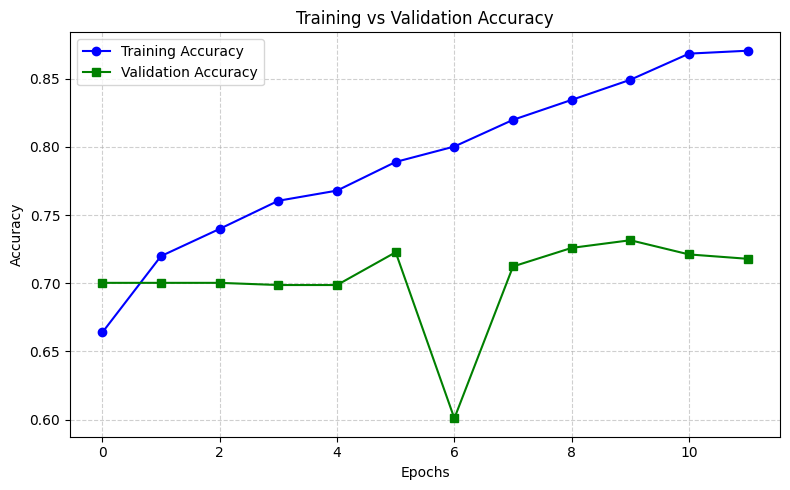

In [102]:
train_val_plot(history_ef.history, 'acc')

<class 'dict'>


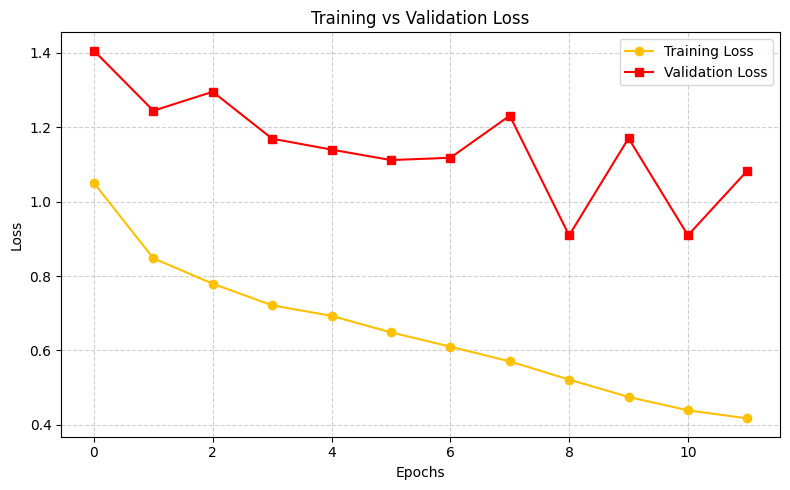

In [114]:
train_val_plot(history_ef.history, 'loss')

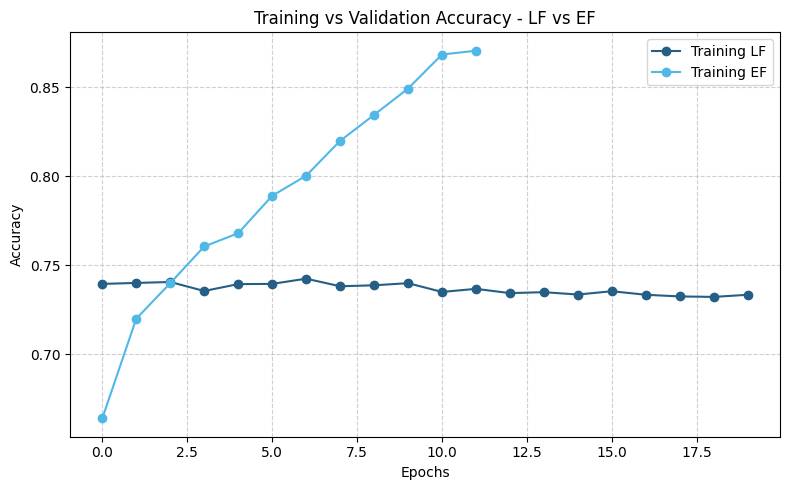

In [106]:
# Plot
plt.figure(figsize=(8, 5))
plt.plot(history_lf.history['accuracy'], label='Training LF' , marker='o', color='#255f85')
plt.plot(history_ef.history['accuracy'], label='Training EF' , marker='o', color='#50b8e7')
plt.title('Training vs Validation Accuracy - LF vs EF' )
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

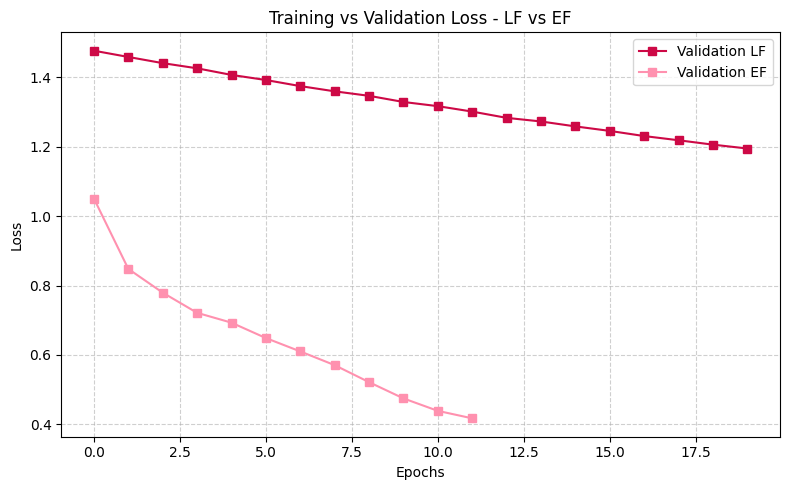

In [108]:
plt.figure(figsize=(8, 5))

plt.plot(history_lf.history['loss'],   label='Validation LF' , marker='s', color='#cd0946')
plt.plot(history_ef.history['loss'],   label='Validation EF' , marker='s', color='#ff91af')
plt.title('Training vs Validation Loss - LF vs EF' )
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Conclusión

Los resultados visualizados muestran una gran disparidad entre las dos formas de fusión. Mientras que en _late fusion_ se completan las epocas inicializadas (20) en _early fusion_ se para en la época 11, consecuencia de la implementación del _EarlyStopping_ para quedarnos con los mejores pesos.

Mientras que la _accuracy_ en LF apenas estaba aprendiendo, con una índice aprox. de 0.74, en EF pasa de 0.66 a 0.87 en 11 épocas.

Ídem con la _loss_ que en LF muestra una pérdida lenta de 1.48 a 1.18 (0.30) mientras qeu EF pasa de 1.05 a 0.42 (0.63, el doble que LF).

## Referencias:


### Weights for unbalanced datasets
- https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html#sklearn.utils.class_weight.compute_class_weight

### Weight imbalance

- Model.fit(class_weight): https://keras.io/api/models/model_training_apis/
- https://medium.com/data-science/class-imbalance-strategies-a-visual-guide-with-code-8bc8fae71e1a
- https://developers.google.com/machine-learning/crash-course/overfitting/imbalanced-datasets
- https://machinelearningmastery.com/weight-regularization-to-reduce-overfitting-of-deep-learning-models/


### CNN regularization
- https://medium.com/intelligentmachines/convolutional-neural-network-and-regularization-techniques-with-tensorflow-and-keras-5a09e6e65dc7


### Early stopping
- https://keras.io/api/callbacks/early_stopping/

### Late fusion
- https://apxml.com/courses/intro-to-multimodal-ai/chapter-3-techniques-integrating-modalities/late-fusion
- https://medium.com/@raj.pulapakura/multimodal-models-and-fusion-a-complete-guide-225ca91f6861